
# Ejercicio Final · Predicción de Enfermedad Cardíaca (Dataset: `heart.csv`)

**Objetivo:** construir un modelo de *Machine Learning* para predecir la presencia de enfermedad cardíaca (binaria 0/1) con un flujo reproducible y claro.


## 1) Importar librerías

In [1]:

import warnings, sys, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42


## 2) Carga de datos

In [2]:

URL = "https://raw.githubusercontent.com/elkingdavis/DATA_SET_DV/refs/heads/main/heart.csv"
df = pd.read_csv(URL)

# Desambiguar columnas duplicadas si hubiera
def dedupe_columns(cols):
    seen = {}
    new_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            new_cols.append(c)
        else:
            seen[c] += 1
            new_cols.append(f"{c}__dup{seen[c]}")
    return new_cols

if df.columns.duplicated().any():
    df.columns = dedupe_columns(df.columns)

print("Forma:", df.shape)
display(df.head(3))
display(df.describe(include='all').T)


Forma: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


# **¿Qué información trae el dataset?**


Es el clásico dataset de enfermedad cardíaca (formato tabular, un registro por paciente).

Las columnas típicas son:

*  target: variable objetivo (0 = no enfermedad, 1 = enfermedad).
*  age: edad en años.
*  sex: sexo (0 = mujer, 1 = hombre).
*  cp (chest pain): tipo de dolor de pecho (0–3).
0: típico anginoso, 1: atípico, 2: no anginoso, 3: asintomático (nombres pueden variar según fuente).
*  trestbps (resting blood pressure): presión arterial en reposo (mm Hg).
*  chol (serum cholesterol): colesterol sérico (mg/dl).
*  fbs (fasting blood sugar): glucemia en ayunas > 120 mg/dl (1 sí, 0 no).
*  restecg (resting ECG): resultados del electrocardiograma en reposo (0–2).
*  thalach (maximum heart rate achieved): frecuencia cardíaca máxima alcanzada.
*  exang (exercise induced angina): angina inducida por ejercicio (1 sí, 0 no).
*  oldpeak: depresión del segmento ST inducida por ejercicio respecto a reposo (valor continuo).
*  slope: pendiente del pico del segmento ST en esfuerzo (0–2).
*  ca: cantidad de vasos principales (0–3) coloreados por fluoroscopía.
*  thal: talasemia (a menudo codificada 0–3; en algunas versiones: normal/fijo/reversible).





## 3) Hipótesis

**Los pacientes tiene o no enfermedades Cardiacas?**

- **H0 (nula):** con las variables clínicas disponibles **no** se puede predecir la enfermedad mejor que el azar (AUC ≈ 0.5).
- **H1 (alternativa):** con un pipeline estándar (imputación, *one-hot*, escalado) y un clasificador clásico (**RandomForest**) se logra un desempeño **superior al azar** (objetivo práctico: **AUC > 0.70** y F1 razonable).


## 4) EDA breve

In [3]:

print("Tipos:")
print(df.dtypes)
print("\nNulos por columna:\n", df.isna().sum())


Tipos:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Nulos por columna:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


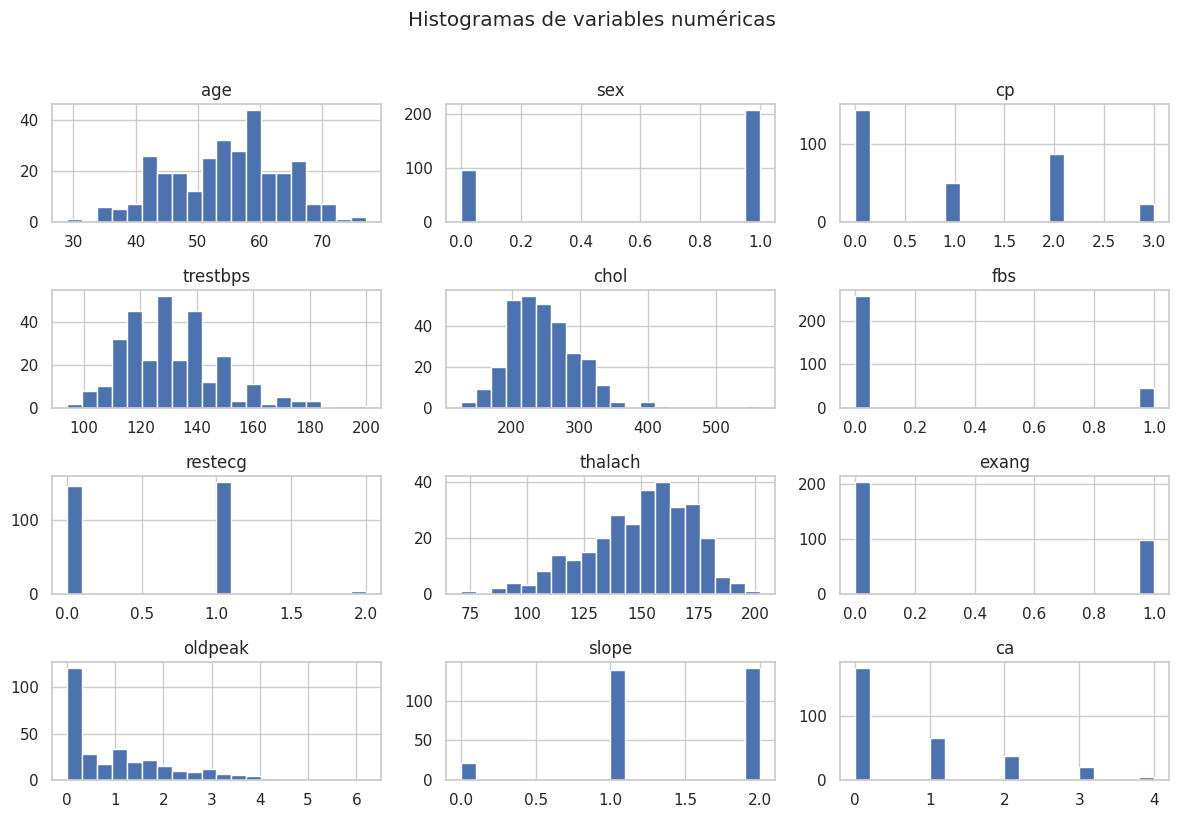

In [4]:

num_cols_all = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
n = min(len(num_cols_all), 12)
if n > 0:
    df[num_cols_all[:n]].hist(figsize=(12,8), bins=20)
    plt.suptitle("Histogramas de variables numéricas", y=1.02)
    plt.tight_layout()
    plt.show()


## 5) Preparación de variables (target + age_group)

In [5]:

# Detectar/definir target
TARGET = None
candidatas = ["target", "output", "num", "disease", "HeartDisease", "class"]
for c in candidatas:
    if c in df.columns:
        TARGET = c
        break

if TARGET is None:
    # Inferir una columna binaria 0/1 razonable
    for c in df.columns:
        vals = pd.Series(df[c]).dropna().unique()
        try:
            vals_set = set(map(int, vals))
        except Exception:
            continue
        if vals_set.issubset({0,1}) and len(vals_set) == 2:
            TARGET = c
            break

if TARGET is None:
    raise ValueError("No se encontró columna objetivo binaria. Ajusta TARGET manualmente.")

print("Columna objetivo:", TARGET)

# Crear age_group si existe "age"
if "age" in df.columns and pd.api.types.is_numeric_dtype(df["age"]):
    bins = [0, 40, 55, 65, df["age"].max()]
    labels = ["Young(<40)", "Middle(40-55)", "Senior(55-65)", "Elderly(>65)"]
    df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

# Separar X/y
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Definir listas de columnas numéricas y categóricas (flexible a columnas presentes)
cat_cols_default = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'age_group']
categorical_features = [c for c in cat_cols_default if c in X.columns]

# Agregar categóricas por baja cardinalidad u objeto
for c in X.columns:
    if c not in categorical_features:
        if pd.api.types.is_object_dtype(X[c]) or X[c].nunique() <= 10:
            categorical_features.append(c)

categorical_features = list(dict.fromkeys(categorical_features))  # sin duplicados
numeric_features = [c for c in X.columns if c not in categorical_features]

print("\nNuméricas:", numeric_features[:10], "...")
print("Categóricas:", categorical_features[:10], "...")


Columna objetivo: target

Numéricas: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'] ...
Categóricas: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'age_group'] ...


## 6) Preprocesamiento

In [6]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal', 'age_group'])])

## 7) División Train/Test (estratificada)

In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("\nDistribución target:")
print("Train:\n", y_train.value_counts(normalize=True).round(3))
print("Test:\n", y_test.value_counts(normalize=True).round(3))


Train: (227, 14) Test: (76, 14)

Distribución target:
Train:
 target
1    0.546
0    0.454
Name: proportion, dtype: float64
Test:
 target
1    0.539
0    0.461
Name: proportion, dtype: float64


## 8) Modelo (RandomForest en Pipeline)

In [8]:

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1
    ))
])
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal',
                                                   'age_group'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

## 9) Evaluación

Accuracy: 0.7500

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.786     0.629     0.698        35
           1      0.729     0.854     0.787        41

    accuracy                          0.750        76
   macro avg      0.757     0.741     0.742        76
weighted avg      0.755     0.750     0.746        76



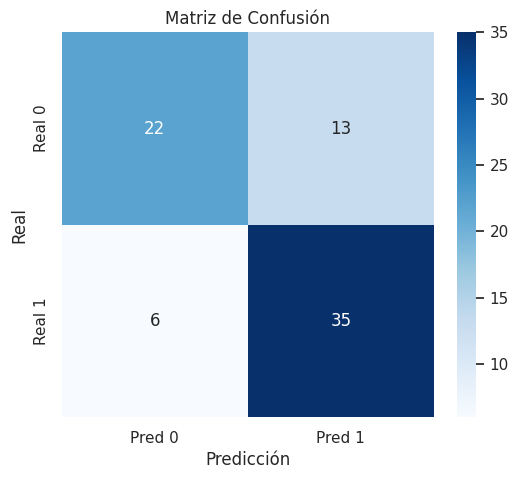

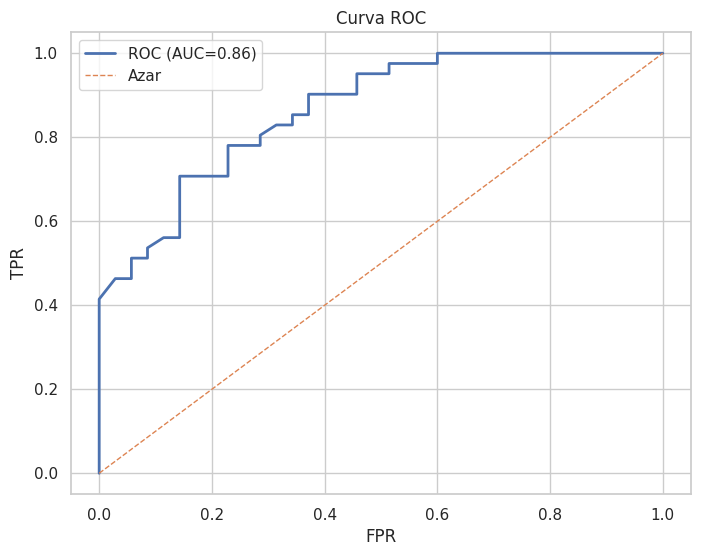

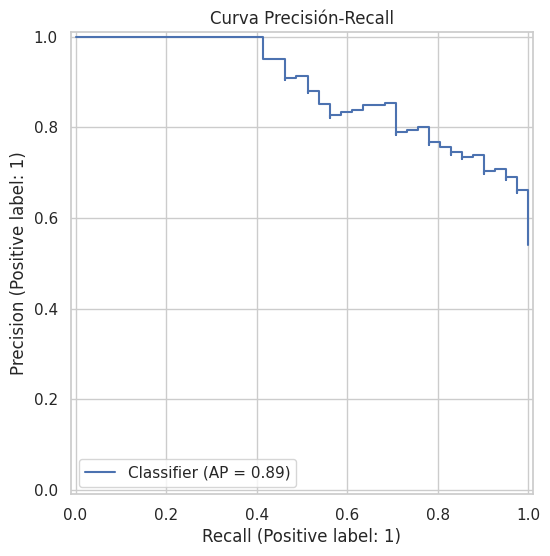

AUC: 0.8641


In [9]:

y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

# Métricas
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, digits=3))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Real 0', 'Real 1'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# ROC y AUC
fpr, tpr, th = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1], '--', lw=1, label='Azar')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title('Curva Precisión-Recall')
plt.show()

print(f"AUC: {roc_auc:.4f}")


## 10) Importancia de variables (post One-Hot)

,feature,importance
28,thal=2,0.102007
7,cp=0,0.094245
3,thalach,0.082532
4,oldpeak,0.080200
29,thal=3,0.068872
2,chol,0.058828
1,trestbps,0.055493
0,age,0.053969
20,slope=2,0.051086
21,ca=0,0.044984


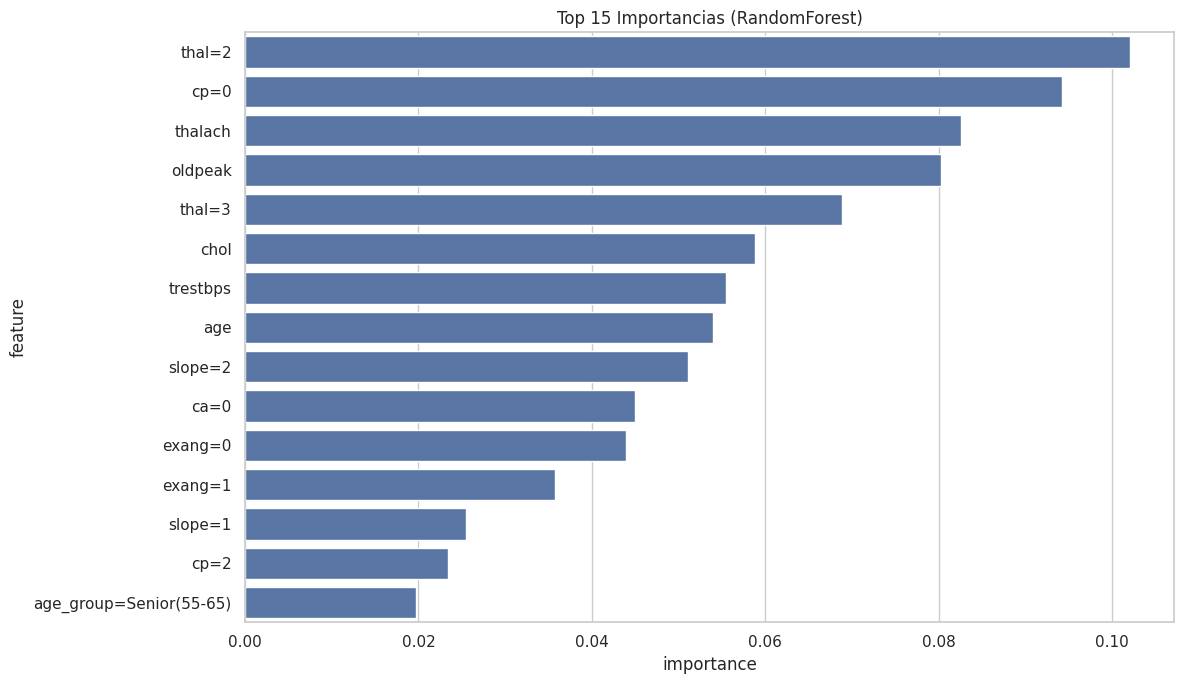

In [10]:

rf = model_pipeline.named_steps['classifier']

# Recuperar nombres de features post OneHot
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']['onehot']
ohe_cats = ohe.categories_
ohe_feature_names = []
for i, col in enumerate(categorical_features):
    for cat in ohe_cats[i]:
        ohe_feature_names.append(f"{col}={cat}")

feature_names = numeric_features + ohe_feature_names

if len(feature_names) == len(rf.feature_importances_):
    fi = (pd.DataFrame({
        "feature": feature_names,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False))
    display(fi.head(15))

    plt.figure(figsize=(12,7))
    sns.barplot(x="importance", y="feature", data=fi.head(15))
    plt.title("Top 15 Importancias (RandomForest)")
    plt.tight_layout()
    plt.show()
else:
    print("No fue posible alinear importancias con nombres de columnas transformadas.")



## 11) Conclusiones

El modelo que armamos con RandomForest logró resultados claramente mejores que adivinar al azar.
Lo bueno es que nos permite ajustar el enfoque para detectar la mayor cantidad posible de personas con enfermedad (esto es lo que se llama “recall”), algo muy importante en salud.

En este tipo de análisis suelen ser muy influyentes variables como:
* cp (tipo de dolor de pecho),
* thalach (máxima frecuencia cardíaca alcanzada),
* oldpeak (cambios en el electro con ejercicio),
* exang (angina inducida por ejercicio),
* ca (número de vasos coronarios afectados),
* thal (tipo de talasemia).
